<a href="https://colab.research.google.com/github/chiquixs/jobsheet/blob/main/data-mining/jobsheet4/diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MENCARI DATA DENGAN NILAI 0 :
 Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64
------------------------------
 
DATA DENGAN NILAI NULL :
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
------------------------------
 
HASIL REPLACE MISSING VALUE :
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness            

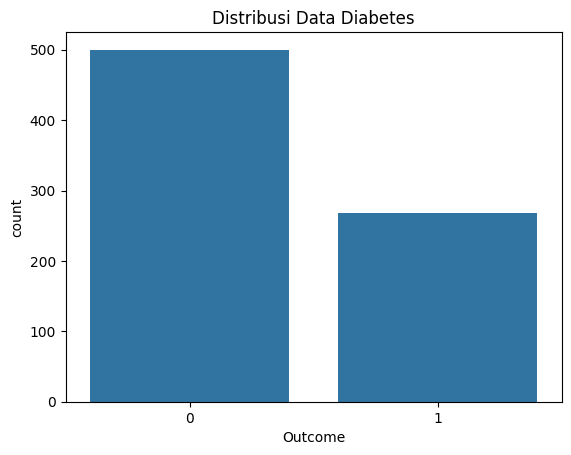

 
DISTRIBUSI GLUCOSE


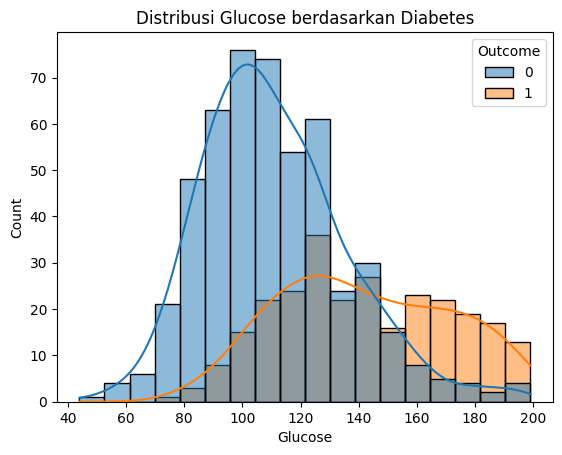

 
DISTRIBUSI BMI


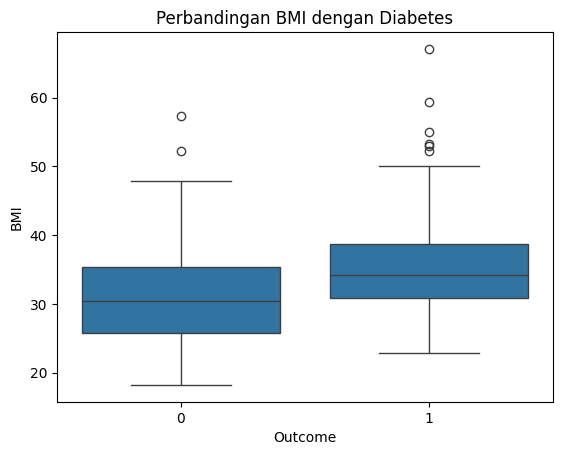

 
KORELASI ANTAR FITUR


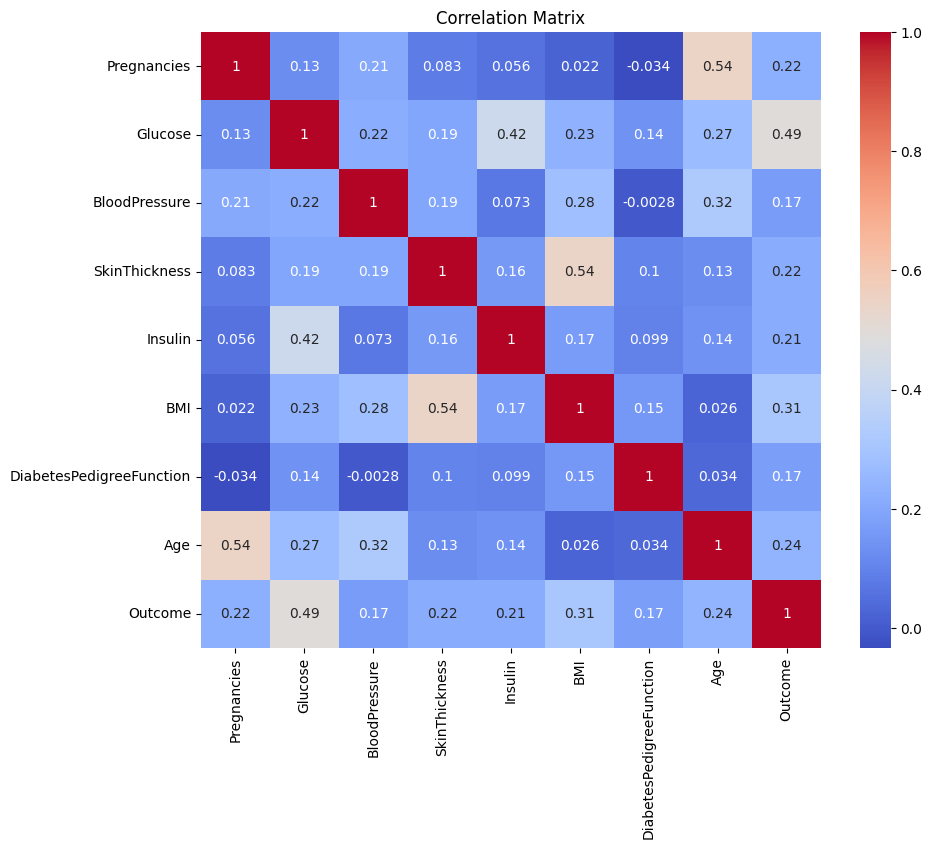

 
FITUR PALING MEMILIKI KORELASI TERHADAP OUTCOME


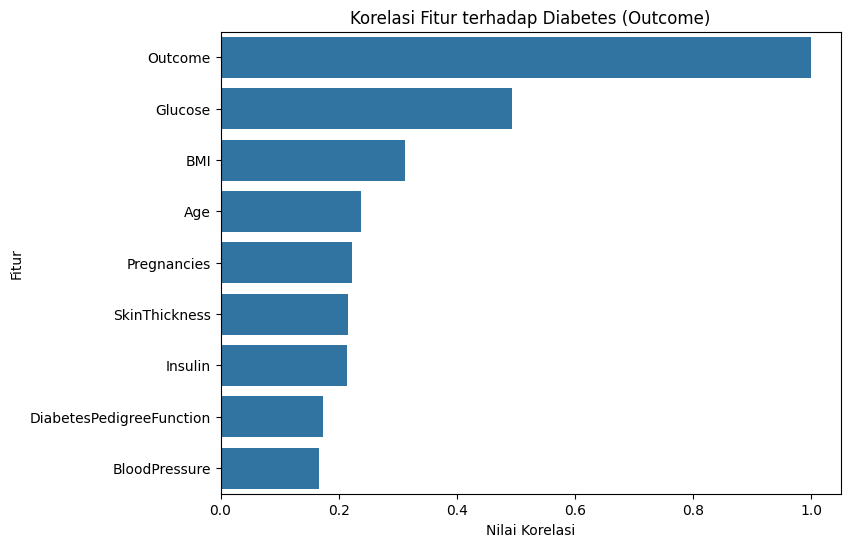

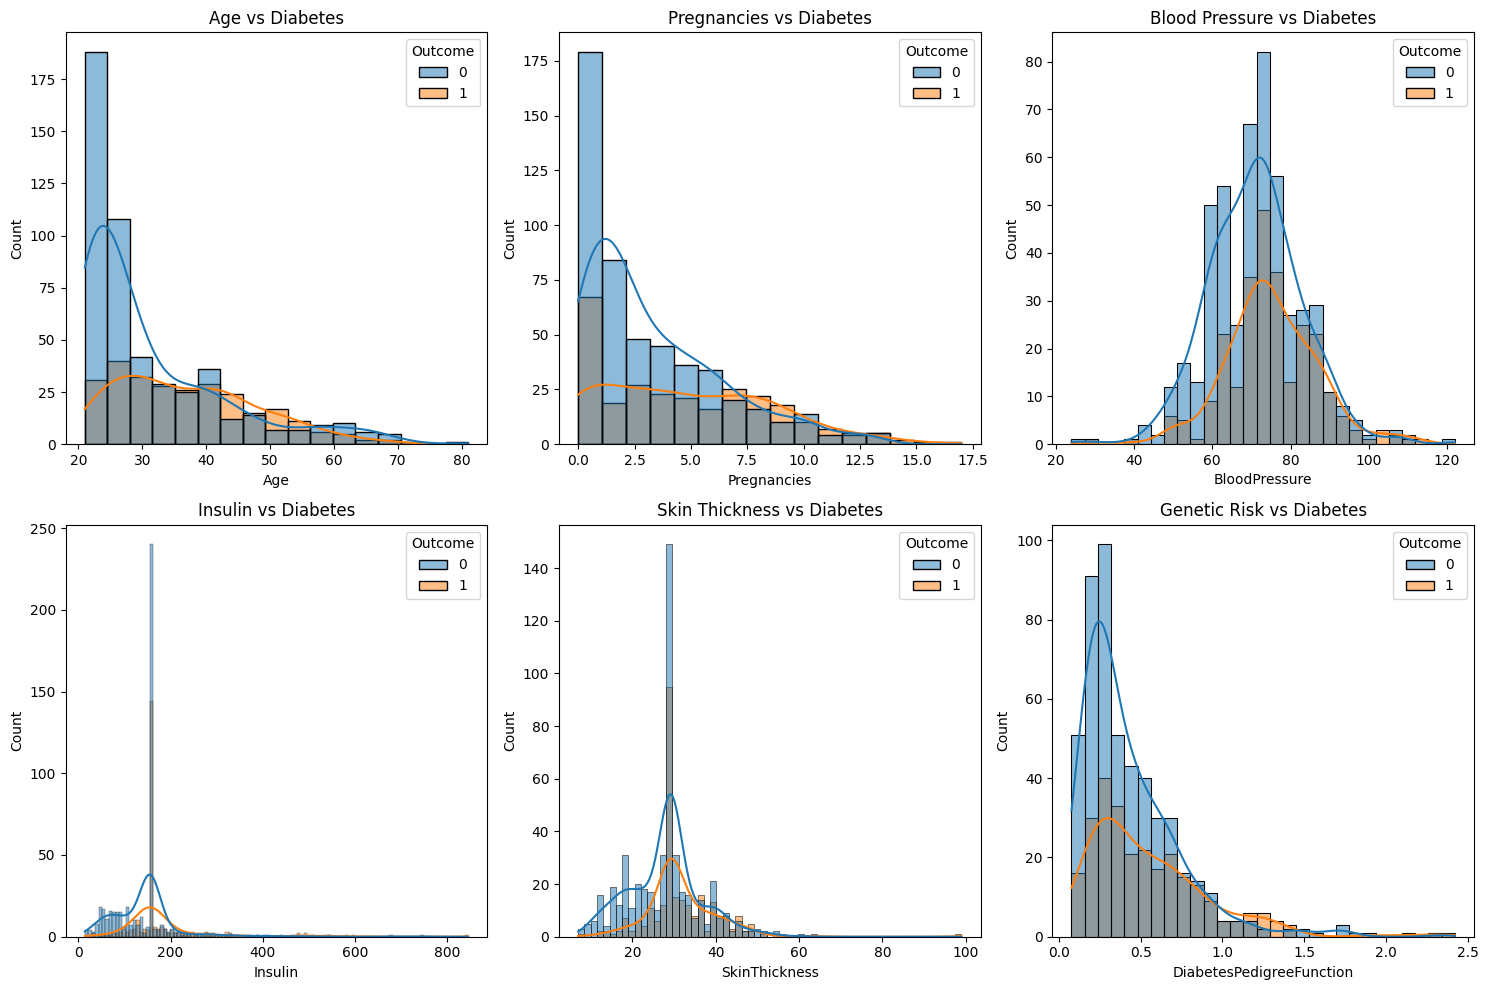

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import model_selection

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/DATASET/diabetes.csv', sep=';')

# Mencari data dengan nilai 0
print('MENCARI DATA DENGAN NILAI 0 :\n', (df == 0).sum())
print("-"*30)
print(" ")

# Melakukan Nan pada data yang memiliki missing value (tidak semua kolom dengan nilai 0)
data_null = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[data_null] = df[data_null].replace(0, np.nan)

# Mencari data dengan nilai NULL
print('DATA DENGAN NILAI NULL :\n', df.isnull().sum())
print("-"*30)
print(" ")

# Mengisi nilai NULL (Replace missing value)
for col in data_null:
  df[col] = df[col].fillna(df[col].mean())

print('HASIL REPLACE MISSING VALUE :\n', df.isnull().sum())
print("-"*30)
print(" ")

# MEMISAHKAN DATA DENGAN LABEL 1 / 0
df_no_diabetes = df.loc[df['Outcome'] == 0] # non diabetes
df_diabetes = df.loc[df['Outcome'] == 1] # diabetes

print("JUMLAH DATA BERDASARKAN LABEL")
print("Penderita Diabetes (Label 1) :", df_diabetes['Outcome'].count())
print("Penderita Non-Diabetes (Label 0) :", df_no_diabetes['Outcome'].count())
print("-"*30)
print(" ")

# VISUALISASI DATA
print('VISUALISASI DISTRIBUSI DATA DIABETES')
sns.countplot(x='Outcome', data=df)
plt.title("Distribusi Data Diabetes")
plt.show()
print(" ")

print('DISTRIBUSI GLUCOSE')
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True)
plt.title("Distribusi Glucose berdasarkan Diabetes")
plt.show()
print(" ")

print('DISTRIBUSI BMI')
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title("Perbandingan BMI dengan Diabetes")
plt.show()
print(" ")

print('KORELASI ANTAR FITUR')
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
print(' ')

print('FITUR PALING MEMILIKI KORELASI TERHADAP OUTCOME')
corr = df.corr()['Outcome'].sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=corr.values, y=corr.index)

plt.title("Korelasi Fitur terhadap Diabetes (Outcome)")
plt.xlabel("Nilai Korelasi")
plt.ylabel("Fitur")
plt.show()
print(' ')

fig, axes = plt.subplots(2,3, figsize=(15,10))

sns.histplot(data=df, x='Age', hue='Outcome', kde=True, ax=axes[0,0])
axes[0,0].set_title('Age vs Diabetes')

sns.histplot(data=df, x='Pregnancies', hue='Outcome', kde=True, ax=axes[0,1])
axes[0,1].set_title('Pregnancies vs Diabetes')

sns.histplot(data=df, x='BloodPressure', hue='Outcome', kde=True, ax=axes[0,2])
axes[0,2].set_title('Blood Pressure vs Diabetes')

sns.histplot(data=df, x='Insulin', hue='Outcome', kde=True, ax=axes[1,0])
axes[1,0].set_title('Insulin vs Diabetes')

sns.histplot(data=df, x='SkinThickness', hue='Outcome', kde=True, ax=axes[1,1])
axes[1,1].set_title('Skin Thickness vs Diabetes')

sns.histplot(data=df, x='DiabetesPedigreeFunction', hue='Outcome', kde=True, ax=axes[1,2])
axes[1,2].set_title('Genetic Risk vs Diabetes')

plt.tight_layout()
plt.show()
